# Scaling TSP to 40-50 Cities Without Quantum Hardware
## Pure GA vs Memetic (GA + 2-opt) vs Multi-start 2-opt

Brute-force is dead beyond N=10 (9! = 362,880 routes). QAOA simulation dies beyond N=5 (16 qubits).
So for 40-50 cities we race three purely classical methods on a laptop:
- **pure_ga**: genetic algorithm only
- **memetic**: GA result polished with 2-opt (uncross the roads)
- **two_opt_x20**: 20 random routes, each polished, keep the best

No optimum is known here, so gap = distance above the **best found by any method** on that map.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from core.city_generator import generate_cities
from algorithms.genetic_algorithm import solve_tsp_genetic
from algorithms.memetic import solve_tsp_memetic
from algorithms.two_opt import two_opt_improve, count_crossings

df = pd.read_csv(os.path.join(ROOT, 'results', 'benchmark_scale.csv'))
print(f'{len(df)} records, methods: {sorted(df.algorithm.unique())}')
print(df.groupby(['algorithm', 'n_cities'])['gap_vs_best'].mean().round(2).to_string())

75 records, methods: ['memetic', 'pure_ga', 'two_opt_x20']
algorithm    n_cities
memetic      10            0.23
             20            1.62
             30            6.11
             40            7.75
             50            4.31
pure_ga      10            1.61
             20           26.66
             30           43.50
             40           73.92
             50          105.64
two_opt_x20  10            0.00
             20            0.00
             30            0.00
             40            0.00
             50            0.00


## 1. Gap vs city count: pure GA collapses, 2-opt family holds

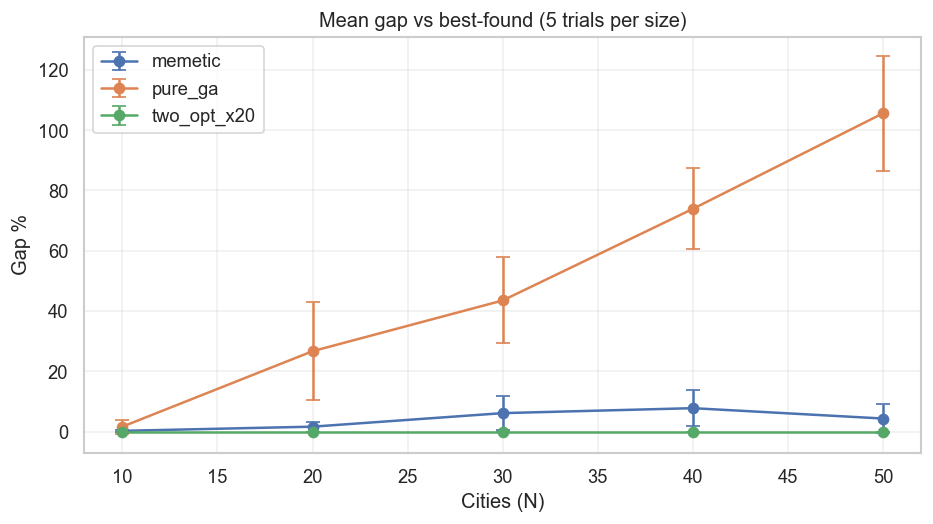

In [2]:
g = df.groupby(['algorithm', 'n_cities'])['gap_vs_best'].agg(['mean', 'std']).reset_index()
plt.figure(figsize=(9, 4.5))
for algo, sub in g.groupby('algorithm'):
    plt.errorbar(sub['n_cities'], sub['mean'], yerr=sub['std'], marker='o', capsize=4, label=algo)
plt.title('Mean gap vs best-found (5 trials per size)')
plt.xlabel('Cities (N)'); plt.ylabel('Gap %'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

## 2. Runtime vs city count

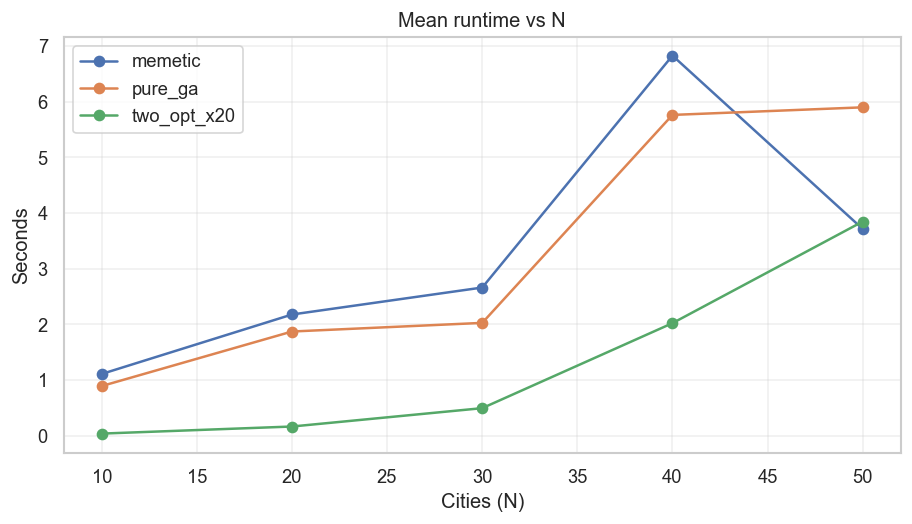

      algorithm  n_cities  time_ms
0       memetic        10   1109.6
1       memetic        20   2176.9
2       memetic        30   2661.1
3       memetic        40   6825.7
4       memetic        50   3712.7
5       pure_ga        10    892.6
6       pure_ga        20   1871.3
7       pure_ga        30   2026.3
8       pure_ga        40   5760.6
9       pure_ga        50   5896.8
10  two_opt_x20        10     38.1
11  two_opt_x20        20    165.4
12  two_opt_x20        30    495.1
13  two_opt_x20        40   2021.4
14  two_opt_x20        50   3845.9


In [3]:
t = df.groupby(['algorithm', 'n_cities'])['time_ms'].mean().reset_index()
plt.figure(figsize=(9, 4.5))
for algo, sub in t.groupby('algorithm'):
    plt.plot(sub['n_cities'], sub['time_ms'] / 1000.0, marker='o', label=algo)
plt.title('Mean runtime vs N')
plt.xlabel('Cities (N)'); plt.ylabel('Seconds'); plt.legend(); plt.grid(alpha=0.3)
plt.show()
print(t.round(1).to_string())

## 3. Before / after: what 2-opt polishing does to a GA route (N=30, live demo)

GA route: 595.7 with 5 crossings  ->  polished: 391.9 with 0 crossings (22 passes)


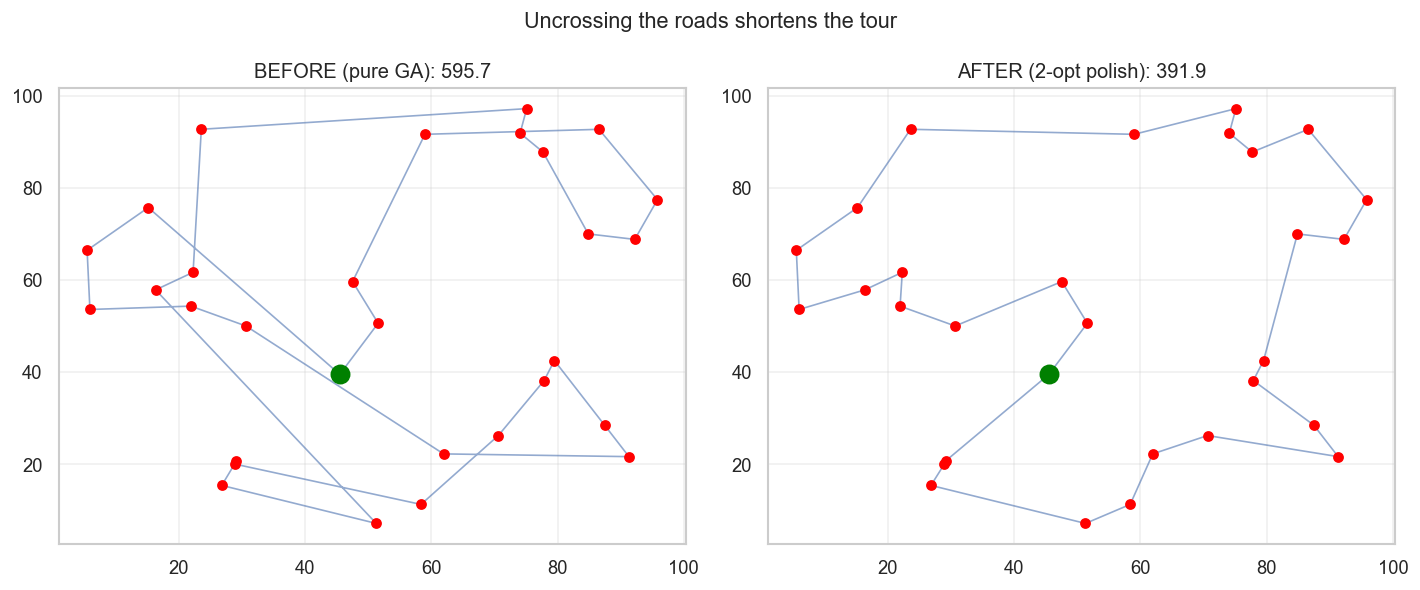

In [4]:
cities = generate_cities(n=30, seed=1030)
ga_route, ga_dist, _ = solve_tsp_genetic(cities, population_size=60, generations=120, mutation_rate=0.05)
x0 = count_crossings(cities, ga_route)
pol_route, pol_dist, passes = two_opt_improve(cities, ga_route)
x1 = count_crossings(cities, pol_route)
print(f'GA route: {ga_dist:.1f} with {x0} crossings  ->  polished: {pol_dist:.1f} with {x1} crossings ({passes} passes)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, route, d, title in [(axes[0], ga_route, ga_dist, 'BEFORE (pure GA)'),
                            (axes[1], pol_route, pol_dist, 'AFTER (2-opt polish)')]:
    rc = cities[route + [route[0]]]
    ax.plot(rc[:, 0], rc[:, 1], 'b-', linewidth=1, alpha=0.6)
    ax.scatter(cities[:, 0], cities[:, 1], c='red', s=30, zorder=5)
    ax.scatter([cities[0, 0]], [cities[0, 1]], c='green', s=120, zorder=6)
    ax.set_title(f'{title}: {d:.1f}')
    ax.grid(alpha=0.3)
plt.suptitle('Uncrossing the roads shortens the tour', fontsize=13)
plt.tight_layout(); plt.show()

## 4. Who won each map? (win table)

algorithm  pure_ga  two_opt_x20
n_cities                       
10               1            4
20               0            5
30               0            5
40               0            5
50               0            5


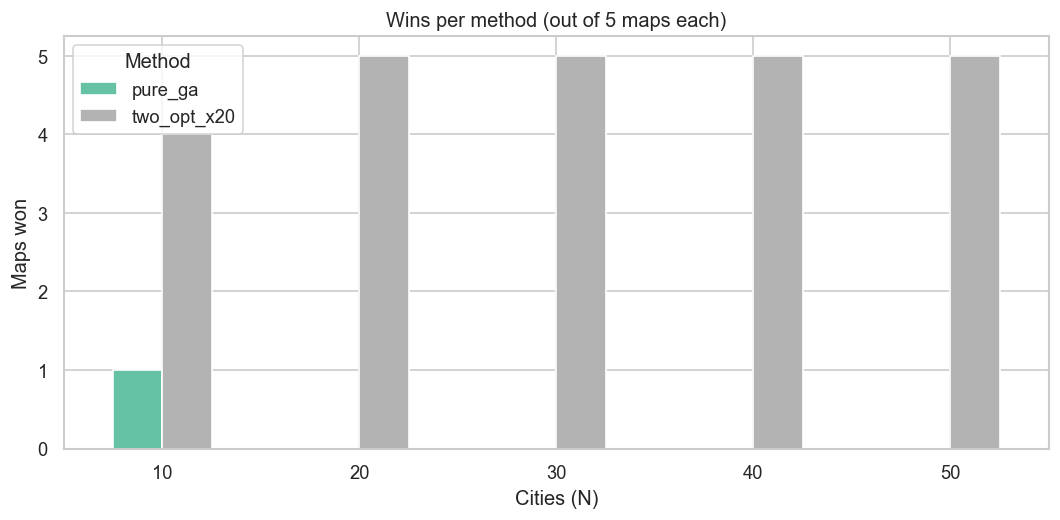

In [5]:
winners = df.loc[df.groupby(['n_cities', 'seed'])['distance'].idxmin()]
tab = pd.crosstab(winners['n_cities'], winners['algorithm'])
print(tab.to_string())
tab.plot(kind='bar', figsize=(9, 4.5), colormap='Set2')
plt.title('Wins per method (out of 5 maps each)')
plt.xlabel('Cities (N)'); plt.ylabel('Maps won'); plt.xticks(rotation=0)
plt.legend(title='Method'); plt.tight_layout(); plt.show()

## 5. Conclusions

### Findings
- **Pure GA degrades catastrophically**: ~27% gap at N=20, ~44% at N=30, ~74% at N=40, ~106% at N=50 (more than 2x worse than best-found). Evolution alone cannot fine-tune large tours.
- **2-opt polishing is the fix**: memetic (GA + polish) stays within 0-8% of best-found at all sizes.
- **Surprise: plain multi-start 2-opt won every map.** 20 random starts x proper convergence beats the GA hybrids here — simple local search with restarts is brutally effective on Euclidean TSP.
- All of this runs in seconds on a laptop. No quantum computer involved.

### Honest limits
- 'Best-found' is not the true optimum (unknown at N=50). Gaps are relative, not absolute.
- Results depend on GA budget (pop 60 x gen 120). Bigger budgets would help pure GA somewhat, but the ranking is stable.
- Euclidean random maps favour 2-opt (crossing removal). Clustered or real road-network maps may differ — next experiment.